In [1]:
import re
import os
import json
import cortex
import pickle
import numpy as np
import pandas as pd
import nibabel as nib
from collections import defaultdict
import matplotlib.pyplot as plt


In [2]:
# load atlases
# read in atlases
# atlas_base_path = "/home/zachkaras/fmri/fmri_model/analysis/pipeline/atlases"
atlas_base_path = "/home/zachkaras/fmri_model/analysis/pipeline/atlases"

# read in 2d mni mask
mask = nib.load(f"{atlas_base_path}/MNI152_T1_2mm_brain_mask.nii.gz")
og_shape = mask.shape
mask = mask.get_fdata().flatten()
brain_idx = np.where(mask>0)[0]

atlas = nib.load(f"{atlas_base_path}/Schaefer2018_400Parcels_7Networks_order_FSLMNI152_2mm.nii.gz")
atlas_vec = atlas.get_fdata().flatten()
atlas_only_brain = atlas_vec[brain_idx] # contains the schaefer parcel numbers
cortex_vx = np.where(atlas_only_brain != 0)[0]
parcel_nums = atlas_only_brain[cortex_vx]

# Making empty templates to save output
empty_schaefer = np.zeros(atlas_only_brain.shape)
empty_mni = np.zeros(atlas_vec.shape)

# demo_data = pd.read_csv("/home/zachkaras/fmri/fmri_model/master-survey-data.csv")
demo_data = pd.read_csv("/home/zachkaras/fmri_model/master-survey-data.csv")

def find_cutoff(vec, threshold = 10**4):
    
    # I can find the threshold point based on sorting, then keep everything in the same place
    copy = vec.copy()
    copy.sort()
    cutoff = copy[-threshold-1]
    return cutoff

def nested_dict():
    return defaultdict(nested_dict)

class Regression_Info(object):
    # [model_name, task, look_ahead, n_delays, layer, stat]
    def __init__(self, model_name=None, task=None, look_ahead=None, n_delays=None, layer=None, stat=None):
        self.model_name = model_name
        self.task       = task
        self.look_ahead = look_ahead
        self.n_delays   = n_delays
        self.layer      = layer
        self.stat       = stat
        
    def __str__(self):
        return f"model: {self.model_name}, task: {self.task}, look-ahead: {self.look_ahead}, n-delays: {self.n_delays}, layer: {self.layer}, stat: {self.stat}"

def parse_regression_info(path):
    
    parts = path.split('-') 
    # example: ['codegemma_7b', 'code', 'look_ahead_by_1', 'ndelays_0', 'layer_28', 'correlations.pkl']
    info = Regression_Info()
    info.model_name = parts[0]
    info.task       = parts[1]
    info.look_ahead = parts[2]
    info.n_delays   = parts[3]
    info.layer      = parts[4]
    info.stat       = (parts[5])[:-4]
    
    return info


def convert_to_nifti(values):
    # working backwards to save correlation values as voxels in MNI space
    empty_schaefer[cortex_vx] = values
    empty_mni[brain_idx] = empty_schaefer
    result_brain = np.reshape(empty_mni, og_shape)

    # Saving results
    nifti_result = nib.Nifti1Image(result_brain, affine=atlas.affine, header=atlas.header)
    nib.save(nifti_result, "test_plotting.nii.gz")
    return result_brain, nifti_result



In [3]:
# looking at specific combinations of parameters
# 4 delays, look ahead by 10
# 16 delays, look ahead by 0
# iterate through directories
# base = "/storage1/fmri_model_data/ridge_regression_pca_params"
# base = "/s1/fmri_model_data/ridge_regression_pca_params"
base = "/data/zachkaras/fmri_model_data/ridge_regression_pca_params"
participants = os.listdir(base)
param1 = r'(?=.*ndelays_4)(?=.*look_ahead_by_10)'
param2 = r'(?=.*ndelays_16)(?=.*look_ahead_by_0)'
stat1 = 'correlations'
stat2 = 'cosine_similarities'

# keep track of stats
top_voxels = nested_dict()
# top_stds  = nested_dict()

for p in participants:
    print(p)
    person_path = f"{base}/{p}"
    person_files = os.listdir(person_path)
    # (?=.*cat)(?=.*dog)
    # person_files = [f for f in person_files if re.search(param1, f)]
    person_files = [f for f in person_files if re.search(param2, f)]
    stat_files = [f for f in person_files if re.search(stat1, f)]
    # print(len(person_files), person_files)
    
    for pkl in stat_files:
        info = parse_regression_info(pkl)
        pickle_path = f"{person_path}/{pkl}"
        
        with open(pickle_path, 'rb') as f:
            corr_values = pickle.load(f)
        cutoff = find_cutoff(corr_values)
        # print(len(stat_vec))
        top_voxel_idx = (np.where(corr_values > cutoff))[0]
        top_voxel_vals = corr_values[top_voxel_idx]
        # corr_values.sort()
        # top_corrs = corr_values[-10**4:]
        # top_mean = np.mean(top_voxel_vals)
        # top_std  = np.std(top_voxel_vals)
        
        top_voxels[p][info.task][info.model_name][info.layer] = top_voxel_vals
        # top_stds[p][info.task][info.model_name][info.layer] = top_std
    
    # break
    

111
117
203
204
129
134
144
133
109
142
150
112
122
141
101
125
108
105
119
121
118
138
151
130
201


In [4]:
participant_performance = defaultdict(list)

# RQ2 - how do the model layers (early vs. late) relate to correlation? For each model, collect correlation values at each layer
layer_performance = nested_dict()

# RQ3 - how do the different models relate to ridge regression performance? Collect correlation values for each model
model_performance = defaultdict(list)

# RQ4 - how do the tasks compare to one another? Collect correlation values for the two tasks
task_performance = defaultdict(list)

for person, taskModelLayerStat in top_voxels.items():
    for task, modelLayerStat in taskModelLayerStat.items():
        if task == 'prose':
            continue
        for model,layerStat in modelLayerStat.items():
            for layer,stat in layerStat.items():
                values = top_voxels[person][task][model][layer]
                # val = top_stds[person][task][model][layer]
                # val = corr_means[person][task][model][layer]
                # val = corr_stds[person][task][model][layer]
                
                participant_performance[person].extend(values)    
                model_performance[model].extend(values)
                task_performance[task].extend(values)
                
                if layer not in layer_performance[model].keys():
                    layer_performance[model][layer] = values
                else:
                    np.append(layer_performance[model][layer], values)

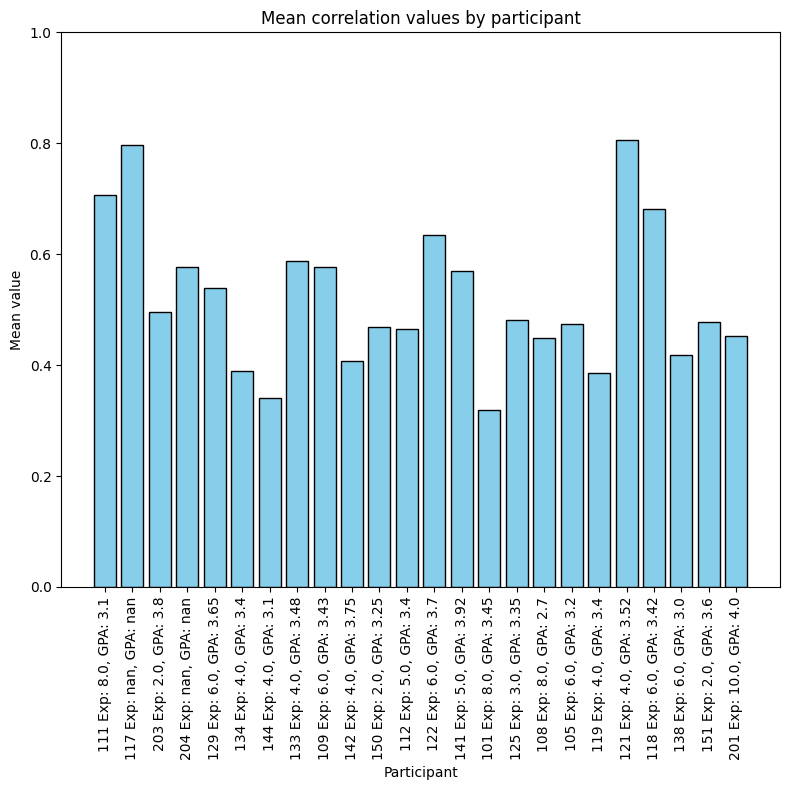

In [7]:
# by participant
def participant_index(id):
    # idx = (np.where(demo_data['id'] == int(id)))[0]
    # print(id, idx)
    return (np.where(demo_data['id'] == int(id)))[0][0]

# Compute means
labels = list(participant_performance.keys())
# Semesters experience and GPA
labels = [f"{l} Exp: {demo_data.loc[participant_index(l), 'semesters_experience']}, GPA: {demo_data.loc[participant_index(l), 'GPA']}" for l in labels]

# code correct and code complete
# labels = [f"{l} Correct: {demo_data.loc[participant_index(l), 'code_correct']}, Complete: {demo_data.loc[participant_index(l), 'code_complete']}" for l in labels]

# code more structured, typing constraints, instinct vs solved
# labels = [f"{l} Structured: {demo_data.loc[participant_index(l), 'Code_more_structured']}, Typing Trouble: {demo_data.loc[participant_index(l), 'Typing Constraints']}, Solved {demo_data.loc[participant_index(l), 'Code_LR_Instinct_vs_Solved']}" for l in labels]

means = [np.mean(v) for v in participant_performance.values()]

# Plot
plt.figure(figsize=(8,8))
plt.bar(labels, means, color='skyblue', edgecolor='black')
plt.ylabel("Mean value")
plt.xlabel("Participant")
plt.xticks(rotation=90)
plt.ylim([0.0, 1])
plt.title("Mean correlation values by participant")
plt.tight_layout()
plt.show()

In [8]:
for model,layers in layer_performance.items():
    l = sorted(layers.keys(), key=lambda x: int(x.split('_')[1]))
    print(f"{model}_layers = {l}")

        

starcoder2_7b_layers = ['layer_0', 'layer_4', 'layer_8', 'layer_12', 'layer_16', 'layer_20', 'layer_24', 'layer_28', 'layer_32']
deepseek_2b_layers = ['layer_0', 'layer_3', 'layer_6', 'layer_9', 'layer_12', 'layer_15', 'layer_18', 'layer_21', 'layer_24']
deepseek_6b_layers = ['layer_0', 'layer_4', 'layer_8', 'layer_12', 'layer_16', 'layer_20', 'layer_24', 'layer_28', 'layer_32']
codegemma_2b_layers = ['layer_0', 'layer_2', 'layer_4', 'layer_6', 'layer_8', 'layer_10', 'layer_12', 'layer_14', 'layer_16', 'layer_18']
starcoder2_3b_layers = ['layer_0', 'layer_4', 'layer_8', 'layer_12', 'layer_16', 'layer_20', 'layer_24', 'layer_28']
codegemma_7b_layers = ['layer_0', 'layer_4', 'layer_8', 'layer_12', 'layer_16', 'layer_20', 'layer_24', 'layer_28']


In [9]:
del layer_performance['deepseek_2b']['layer_15']
del layer_performance['codegemma_2b']['layer_2']
del layer_performance['codegemma_2b']['layer_8']
del layer_performance['deepseek_6b']['layer_20']
del layer_performance['starcoder2_7b']['layer_24']

In [1]:
# layer bar chart
# layer_performance = json.loads(json.dumps(layer_performance))

models = list(layer_performance.keys())
layers = list(next(iter(layer_performance.values())).keys())  # assume all participants have same tasks

layers = sorted(
    next(iter(layer_performance.values())).keys(),
    key=lambda x: int(x.split('_')[1])
)

# Compute means
# means = {p: [np.mean(data[p][t]) for t in tasks] for p in participants}
means = {}
for model, layerScores in layer_performance.items():
    layers = sorted(layerScores.keys(), key=lambda x: int(x.split('_')[1]))
    for layer in layers:
    # for layer,scores in layerScores.items():
        # print(model, layer)
        scores = layer_performance[model][layer]
        # print(np.mean(scores), scores)
        if model not in means.keys():
            # means[model] = [np.mean(scores)]
            means[model] = [scores]
        else:
            # print(model, layer, scores)
            # means[model].append(np.mean(scores))
            means[model].append(scores)
    #     break
    # break
            
# means = {m: [layer_performance[m][l] for l in layers] for m in models}
# print(layers)
# print([means[m][0] for m in models])
# Plot grouped bars
x = np.arange(len(models))  # positions for participants
width = 0.35 / len(layers) * 2     # adjust width depending on number of tasks

plt.figure(figsize=(8,6))
for i, layer in enumerate(layers):
    plt.bar(x + i*width, [np.mean(means[m][i]) for m in models],
            width, label=layer, edgecolor='black')

plt.xlabel("Model")
plt.ylim([0.0,1])
plt.ylabel("Mean Score")
plt.title("Layer correlations per participant with PCA")
plt.xticks(x + width*(len(layers)-1)/2, models, rotation=45, ha='right')
plt.legend(title="Layer", loc='lower right')
plt.tight_layout()
plt.show()

NameError: name 'layer_performance' is not defined

In [ ]:
# brain plots
# participants 117 and 204
# maybe codegemma 7b?
participant = '117'
# participant = '121'
# participant = '204'
filepath = f"{base}/{participant}"
# pattern = r'(?=.*codegemma_7b)(?=.*ndelays_4)(?=.*look_ahead_by_10)'
pattern = r'(?=.*codegemma_7b)(?=.*ndelays_16)(?=.*look_ahead_by_0)'
# param1 = r'(?=.*ndelays_4)(?=.*look_ahead_by_10)'
# param2 = r'(?=.*ndelays_16)(?=.*look_ahead_by_0)'
brain_files = [f for f in os.listdir(filepath) if re.search(pattern, f) and re.search("correlations", f) and re.search("-code-", f)]

In [ ]:
for brain in brain_files:
    print(brain)
    brainpath = f"{filepath}/{brain}"
    with open(brainpath, 'rb') as f:
        data = pickle.load(f)

    npy_brain, nifti_brain = convert_to_nifti(data)
    npy_brain = npy_brain.transpose(2,1,0)
    
    vol = cortex.Volume(
    npy_brain,
    subject='fsaverage',
    xfmname='mni2py2',
    )
    cortex.webshow(vol)
    # break


In [ ]:
vol = cortex.Volume(
    npy_brain,
    subject='fsaverage',
    xfmname='mni2py2',
)

In [ ]:
cortex.webshow(vol)

In [ ]:
with open('results/participant_parcel_enrichment_results.pkl', 'rb') as f:
    result_dict = pickle.load(f)


schaefer_labels = "schaefer_parcel_labels.pkl"
with open(schaefer_labels, 'rb') as f:
    region_labels = pickle.load(f)

def translate_to_region_name(parcel_num):
    parcel_num = int(parcel_num)
    if parcel_num < 200:
        region = schaefer_labels['left'][parcel_num]
    else:
        region = schaefer_labels['right'][parcel_num]
    return region

In [ ]:
from collections import Counter                                                                                                                                                                                                                                                                                  
   
# counts = Counter(my_list)  

for m,l_p in result_dict.items():
    for l,p_results in l_p.items():
        for p, results in p_results.items():
            enriched = results['enriched_parcels']
            enriched_regions = [translate_to_region_name(parcel_num) for parcel_num in enriched]
            print(p, enriched_regions)
            # print(p, m, l, results)
            # for parcel in enriched parcels
            # translate 

TypeError: string indices must be integers, not 'str'

In [ ]:
# read in pickle file of 


In [ ]:
parcels_of_interest = {
    'theory' : [133,172,192,284,339,395],
    'data_driven' : [9,67,176,183,231,242,341,343,348,380,386,389,391]
}
# theory_parcels = [133,172,192,284,339,395]
# # Data driven seed values
# data_driven_parcels = [9,67,176,183,231,242,341,343,348,380,386,389,391]

# important demographics: age, years experience, GPA, Code_more_structured, 
# correct, complete, code_correct, code_complete
variables = {
    'GPA': 'GPA',
    'Age': 'age',
    'Years of Experience': 'years_experience',
    # 'Code Editing' : 'code_editing_rate',
    # 'Prose Editing' : 'prose_editing_rate',
    # 'Code Total Keystrokes' : 'code_total_keystrokes',
    # 'Prose Total Keystrokes' : 'prose_total_keystrokes',
    # 'Code More Structured' : 'Code_more_structured', 
    'Correct' : 'correct',
    'Complete' : 'complete',
    'Code Correct' : 'code_correct',
    'Code Complete' : 'code_complete'
}

demo_data = pd.read_csv("/home/zachkaras/fmri_model/master-survey-data.csv")
demo_data['years_experience'] = demo_data['semesters_experience'] / 2
# demo_data['code_more_structured'] = demo_data['Code_more_structured'].map({'X': 0, 'Y': 1})
demo_data = demo_data.set_index('id')
print(demo_data[['age', 'GPA', 'years_experience']].describe())


def find_parcel_voxels(parcel_num):
    parcel_idx = list((np.where(parcel_nums == parcel_num))[0])
    print(len(parcel_idx), parcel_idx)


from scipy import stats

def find_cutoff(vec, threshold=10**4):
    copy = vec.copy()
    copy.sort()
    return copy[-threshold - 1]

best_models = ['code-deepseek_6b-ndelays_4-look_ahead_by_10',
               'code-codegemma_7b-ndelays_4-look_ahead_by_10',
               'code-codegemma_7b-ndelays_16-look_ahead_by_0',
               'prose-codegemma_7b-ndelays_10-look_ahead_by_5',
               'prose-deepseek_6b-ndelays_20-look_ahead_by_10']

participant_base_path = "/data/zachkaras/fmri_model_data/ridge_regression_pca_params"
participants = os.listdir(participant_base_path)

# participant_means[model][layer_num][participant_id] = mean z-scored correlation

# For each of the best models, for each of the parcel values

# for each parcel of interest, find voxels in participant corresponding to that parcel
# average the correlation coefficients for that parcel to give one value per participant
# correlate these values with demographic variables of interest



parcel_means = {}

for m in best_models:
    parts = m.split('-')
    task, model, delays, look_ahead = parts[0], parts[1], parts[2], parts[3]

    parcel_means[m] = {}
    for p in participants:
        print(p)
        files = os.listdir(f"{participant_base_path}/{p}")
        pattern = f"{model}-{task}-{look_ahead}-{delays}"
        best_files = [f for f in files if re.search(pattern, f) and 'correlations' in f]
        print(best_files)
        for bf in best_files:
            print("hello")

            layer_num = int(re.search(r'layer_(\d+)', bf).group(1))
            print(layer_num)
            if layer_num not in parcel_means[m]:
                parcel_means[m][layer_num] = {}
            with open(f"{participant_base_path}/{p}/{bf}", 'rb') as f:
                corrs = pickle.load(f)
            z = np.arctanh(corrs)
            for approach in ['theory', 'data_driven']:
                for parcel in parcels_of_interest[approach]:
                    print("hello hello")
                    find_parcel_voxels(parcel)
                    
                    break
                break
            break
        break
    break

            # cutoff = find_cutoff(z)

In [ ]:
records = []

for m in best_models:
    parts = m.split('-')
    task, model, delays, look_ahead = parts[0], parts[1], parts[2], parts[3]
    pattern = f"{model}-{task}-{look_ahead}-{delays}"

    for p in participants:
        files = os.listdir(f"{participant_base_path}/{p}")
        best_files = [f for f in files if re.search(pattern, f) and 'correlations' in f]

        # Accumulate per-layer means for each parcel, then average across layers
        layer_vals = defaultdict(list)  # (approach, parcel) -> [layer_mean, ...]

        for bf in best_files:
            with open(f"{participant_base_path}/{p}/{bf}", 'rb') as f:
                corrs = pickle.load(f)
            z_corrs = np.arctanh(corrs)

            for approach, parcels in parcels_of_interest.items():
                for parcel in parcels:
                    layer_vals[(approach, parcel)].append(
                        np.mean(find_parcel_voxels(parcel, z_corrs))
                    )

        # One row per participant × model × parcel, averaged across layers
        for (approach, parcel), vals in layer_vals.items():
            records.append({
                'model': m,
                'participant': int(p),
                'approach': approach,
                'parcel': parcel,
                'mean_z_corr': np.mean(vals),
            })

df = pd.DataFrame(records)
df = df.merge(demo_data[list(variables.values())], left_on='participant', right_index=True)

Then stats are just:

from scipy import stats

stat_records = []
for (model, approach, parcel), group in df.groupby(['model', 'approach', 'parcel']):
    for label, col in variables.items():
        r, p = stats.spearmanr(group['mean_z_corr'], group[col], nan_policy='omit')
        stat_records.append({
            'model': model, 'approach': approach, 'parcel': parcel,
            'variable': label, 'r': r, 'p': p
        })

stats_df = pd.DataFrame(stat_records)